In [3]:
lib_path ="/home/tibia/Projet_Hemorragie/Seg_hemorragie/Segmentation"
import sys
sys.path.append(lib_path)

In [4]:
from monai.data import DataLoader, PersistentDataset

import torch
import os


import data.dataset as dataset
import data.transform as T_seg

import config 
import wandb
#from models.lightning import HemorrhageModel

import warnings

/home/tibia/miniconda3/envs/hemorragie-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/tibia/miniconda3/envs/hemorragie-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may h

In [ ]:
import SimpleITK as sitk
from monai.transforms import LoadImage
import numpy as np

cfg=config.CONFIG
        # Logger W&B
        # ---------------------------


        # ---------------------------
        # Load data
        # ---------------------------

# Exemple d'utilisation



   
train_files = dataset.get_data_files(f"{cfg['dataset']['dataset_dir']}/train/img",
                                            f"{cfg['dataset']['dataset_dir']}/train/seg")
val_files = dataset.get_data_files(f"{cfg['dataset']['dataset_dir']}/val/img",
                                        f"{cfg['dataset']['dataset_dir']}/val/seg")

test_files = dataset.get_data_files(f"{cfg['dataset']['dataset_dir']}/test/img",
                                        f"{cfg['dataset']['dataset_dir']}/test/seg")


for sample in test_files:
    seg_path = sample["seg"]

    img = sitk.ReadImage(seg_path)
    arr = sitk.GetArrayFromImage(img)

    unique_vals = np.unique(arr)


    print(f"{seg_path} -> {unique_vals}")
    
test_dataset = PersistentDataset(
            test_files,
            transform=T_seg.get_val_transforms(cfg),
            cache_dir=os.path.join(cfg['dataset']['save_dir'], "cache_val")
        )

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=8)






/home/tibia/Projet_Hemorragie/Datasets/mbh/Split_Final_Stratified/test/seg/MBH_SEG_2025_LLG_2025_06_12_ID_02b882cc_ID_a4892e60ae.nii.gz -> [0 2 3 4]
/home/tibia/Projet_Hemorragie/Datasets/mbh/Split_Final_Stratified/test/seg/MBH_SEG_2025_LLG_2025_06_12_ID_10beb45f_ID_7184e80f09.nii.gz -> [0 2]
/home/tibia/Projet_Hemorragie/Datasets/mbh/Split_Final_Stratified/test/seg/MBH_SEG_2025_LLG_2025_06_12_ID_1cbe2853_ID_37afefdc7c.nii.gz -> [0 2]
/home/tibia/Projet_Hemorragie/Datasets/mbh/Split_Final_Stratified/test/seg/MBH_SEG_2025_LLG_2025_06_12_ID_268b38fe_ID_d747ae3ffb.nii.gz -> [0 2 3 4 5]
/home/tibia/Projet_Hemorragie/Datasets/mbh/Split_Final_Stratified/test/seg/MBH_SEG_2025_LLG_2025_06_12_ID_2872834a_ID_542e9d00da.nii.gz -> [0 1]
/home/tibia/Projet_Hemorragie/Datasets/mbh/Split_Final_Stratified/test/seg/MBH_SEG_2025_LLG_2025_06_12_ID_2e21c3f3_ID_bc8f99a0cc.nii.gz -> [0 5]
/home/tibia/Projet_Hemorragie/Datasets/mbh/Split_Final_Stratified/test/seg/MBH_SEG_2025_LLG_2025_06_12_ID_3343ddf2_ID_fd

Fichier testé : /home/tibia/Projet_Hemorragie/Split_Final_Stratified/train/img/MBH_SEG_2025_LLG_2025_06_12_ID_029ebbea_ID_563afa0901.nii.gz
Spacing (dx, dy, dz) : [0.488281 0.488281 5.392519]
torch.Size([512, 512, 26])
Taille physique du volume : 250.0mm x 250.0mm x 140.2mm

--- Après LoadImageD ---
Shape: (512, 512, 26) | Min: -3024.00 | Max: 2119.00 | Mean: -1120.00


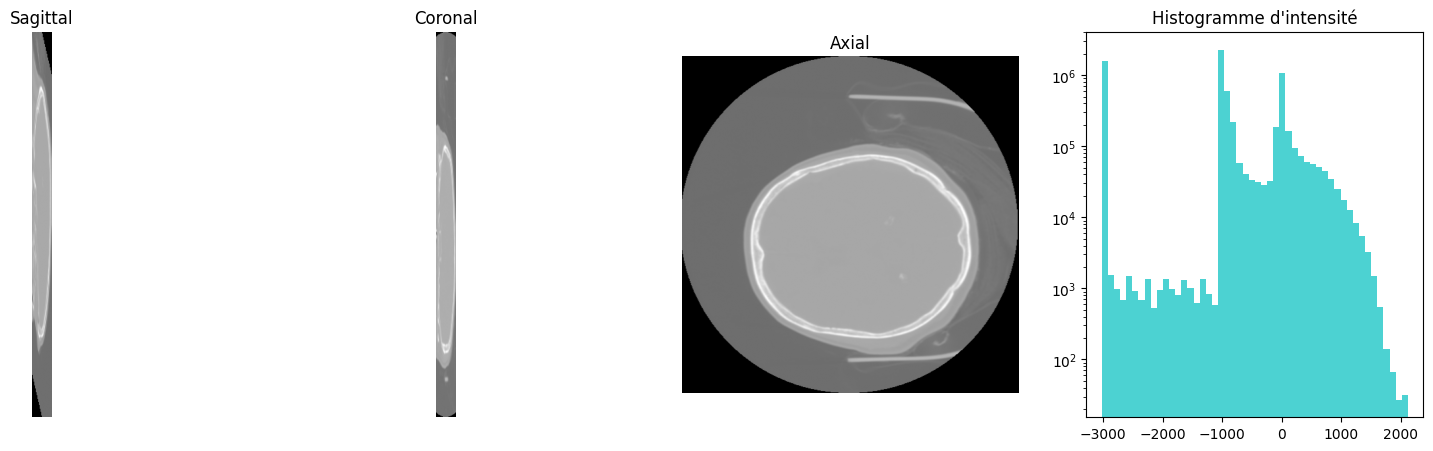

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import monai.transforms as T
import torch

def visualize_step(data_dict, step_name, key='image'):
    """Affiche les coupes centrales et l'histogramme des intensités."""
    vol = data_dict[key]
    if isinstance(vol, torch.Tensor):
        vol = vol.numpy()
    
    # Si channel first (C, D, H, W), on prend le canal 0
    if vol.ndim == 4:
        vol = vol[0]
        
    shape = vol.shape
    print(f"\n--- {step_name} ---")
    print(f"Shape: {shape} | Min: {vol.min():.2f} | Max: {vol.max():.2f} | Mean: {vol.mean():.2f}")

    # Coupes centrales
    slice_0 = vol[shape[0] // 2, :, :] # Sagittal
    slice_1 = vol[:, shape[1] // 2, :] # Coronal
    slice_2 = vol[:, :, shape[2] // 2] # Axial
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Affichage des coupes
    for i, (sl, title) in enumerate(zip([slice_0, slice_1, slice_2], ['Sagittal', 'Coronal', 'Axial'])):
        axes[i].imshow(sl, cmap='gray', origin='lower')
        axes[i].set_title(f"{title}")
        axes[i].axis('off')

    # Affichage Histogramme (Pour vérifier la normalisation)
    axes[3].hist(vol.flatten(), bins=50, color='c', alpha=0.7)
    axes[3].set_title("Histogramme d'intensité")
    axes[3].set_yscale('log') # Log scale pour voir les petites variations
    
    plt.show()

# --- CHARGEMENT D'UN FICHIER EXEMPLE ---
# On prend le premier fichier de ta liste train_files
sample_data = train_files[0] 
print(f"Fichier testé : {sample_data['image']}")

# Chargement avec MONAI
loader = T.LoadImageD(keys=['image', 'seg'], image_only=False)
data = loader(sample_data)
image_meta = data['image_meta_dict']
pixdim = image_meta.get("pixdim", "Non trouvé")
# Souvent le spacing est dans les indices 1, 2, 3 de pixdim
print(f"Spacing (dx, dy, dz) : {pixdim[1:4]}")
shape = data['image'].shape
print (shape) # On ignore le canal
print(f"Taille physique du volume : {shape[0]*pixdim[1]:.1f}mm x {shape[1]*pixdim[2]:.1f}mm x {shape[2]*pixdim[3]:.1f}mm")
visualize_step(loader(sample_data), "Après LoadImageD")

In [12]:
import nibabel as nib
img = nib.load("/home/tibia/Projet_Hemorragie/nnUNet/nnUNet_raw/Dataset003_WinMultiICHv4/imagesTr/ID_0ad8b9c0_instUid_ID_406023c8f_0000.nii.gz")
print(f"Dimensions : {img.shape}")
print(f"Spacing réel (mm) : {img.header.get_zooms()[:3]}")

Dimensions : (512, 512, 34)
Spacing réel (mm) : (0.4949, 0.4949, 5.0)



--- ÉTAPE 1 : Physique (Spacing 1mm + RAS) ---
Shape: (251, 251, 136) | Min: -3024.00 | Max: 2095.85 | Mean: -1127.49


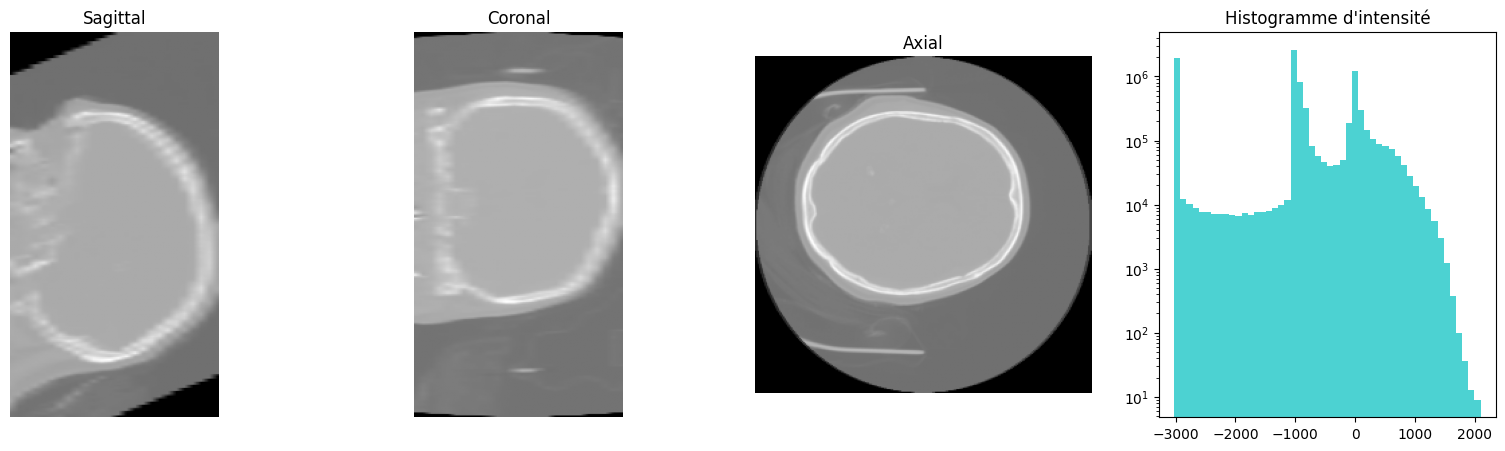

In [20]:
step1_transforms = T.Compose([
    T.LoadImaged(keys=["image", "seg"]),
    #T.CropForegroundd(keys=['image', 'seg'], source_key='image'),
    T.EnsureChannelFirstd(keys=["image", "seg"]),
    T.Orientationd(keys=["image", "seg"], axcodes='RAS'),
    T.Spacingd(keys=["image", "seg"], pixdim=(1, 1, 1), mode=['bilinear', 'nearest']),
])

# Exécution
data_step1 = step1_transforms(sample_data)
visualize_step(data_step1, "ÉTAPE 1 : Physique (Spacing 1mm + RAS)")

/home/tibia/Projet_Hemorragie/hemorragie-env/lib/python3.12/site-packages/monai/utils/deprecate_utils.py:321: FutureWarning: monai.transforms.croppad.dictionary CropForegroundd.__init__:allow_smaller: Current default value of argument `allow_smaller=True` has been deprecated since version 1.2. It will be changed to `allow_smaller=False` in version 1.5.
  warn_deprecated(argname, msg, warning_category)



--- ÉTAPE 2 : Normalisation (0.0 à 1.0) ---
Shape: (199, 192, 136) | Min: 0.00 | Max: 1.00 | Mean: 0.22


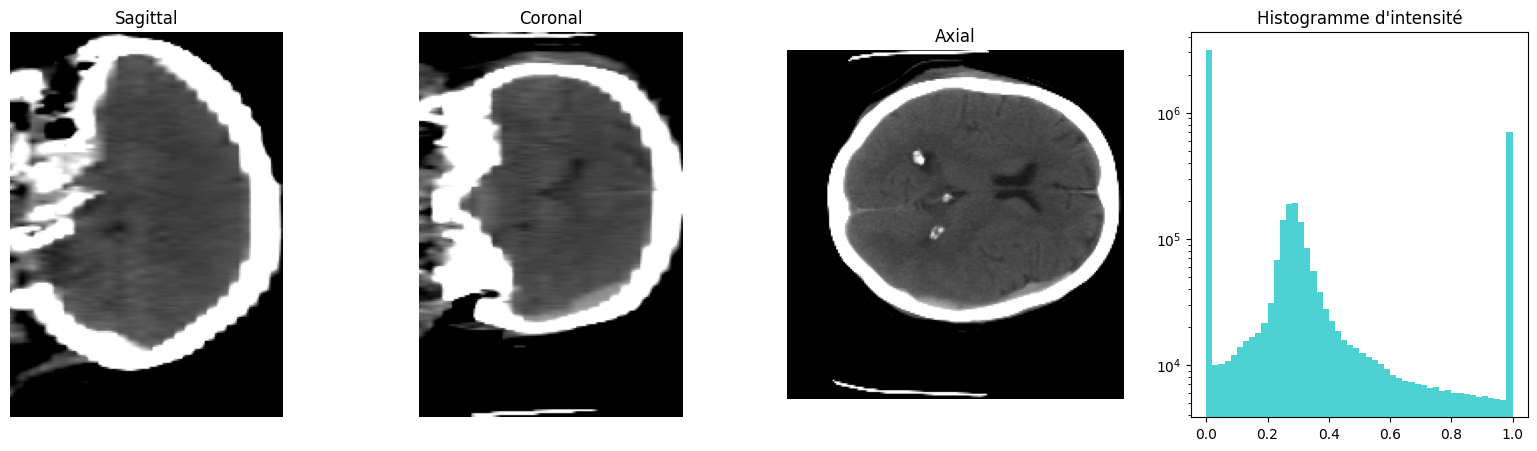

In [22]:
step2_transforms = T.Compose([
    T.ScaleIntensityRanged(
        keys=["image"],
        a_min=-10, a_max=140, # Ta fenêtre Stroke
        b_min=0.0, b_max=1.0,
        clip=True
    ),
T.CropForegroundd(keys=['image', 'seg'], source_key='image'),
])

# On applique sur le résultat de l'étape précédente
data_step2 = step2_transforms(data_step1) # On continue la chaîne
visualize_step(data_step2, "ÉTAPE 2 : Normalisation (0.0 à 1.0)")


--- ÉTAPE 4 : Patching (Focus Lésion) ---
Shape: (96, 96, 96) | Min: 0.00 | Max: 1.00 | Mean: 0.27


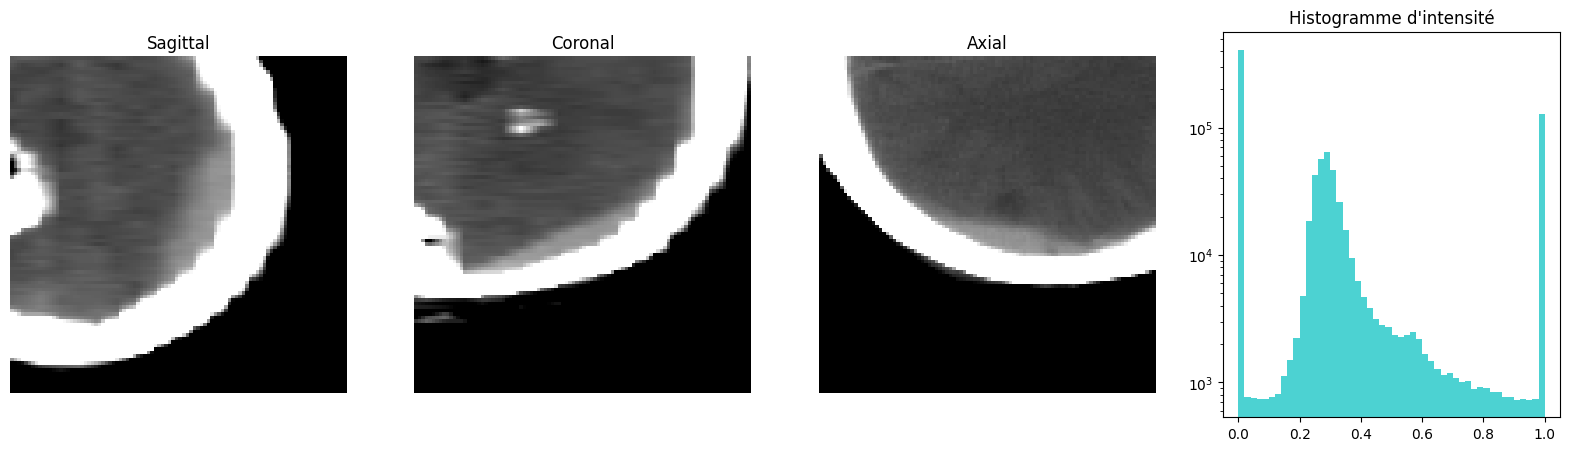

✅ SUCCÈS : Le patch contient une hémorragie !

--- MASQUE DU PATCH ---
Shape: (96, 96, 96) | Min: 0.00 | Max: 5.00 | Mean: 0.11


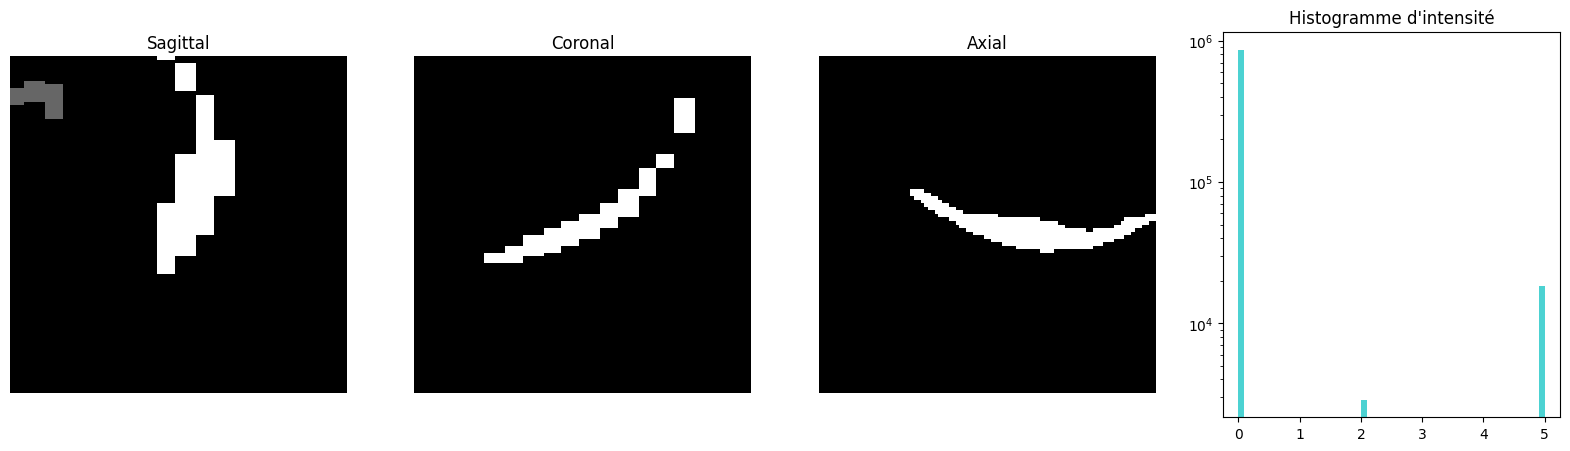

In [25]:
step4_transforms = T.RandCropByPosNegLabeld(
    keys=['image', 'seg'],
    image_key='image',
    label_key='seg',
    pos=5.0, # Ton réglage agressif
    neg=1.0, 
    spatial_size=[96, 96, 96],
    num_samples=1 # On en regarde juste un pour l'exemple
)

# Attention: RandCrop renvoie une LISTE de patchs
patch_list = step4_transforms(data_step2)
data_step4 = patch_list[0] 

visualize_step(data_step4, "ÉTAPE 4 : Patching (Focus Lésion)")

# Vérifions si on a chopé une hémorragie (seg > 0)
seg_patch = data_step4['seg']
if seg_patch.max() > 0:
    print("✅ SUCCÈS : Le patch contient une hémorragie !")
    # Affichons le masque pour être sûr
    visualize_step(data_step4, "MASQUE DU PATCH", key='seg')
else:
    print("⚠️ ATTENTION : Le patch est sain (C'est normal parfois, mais vérifie si c'est fréquent).")


--- ÉTAPE 5 : Augmentations (Bruit + Flip) ---
Shape: (192, 192, 24) | Min: -0.19 | Max: 1.19 | Mean: 0.27


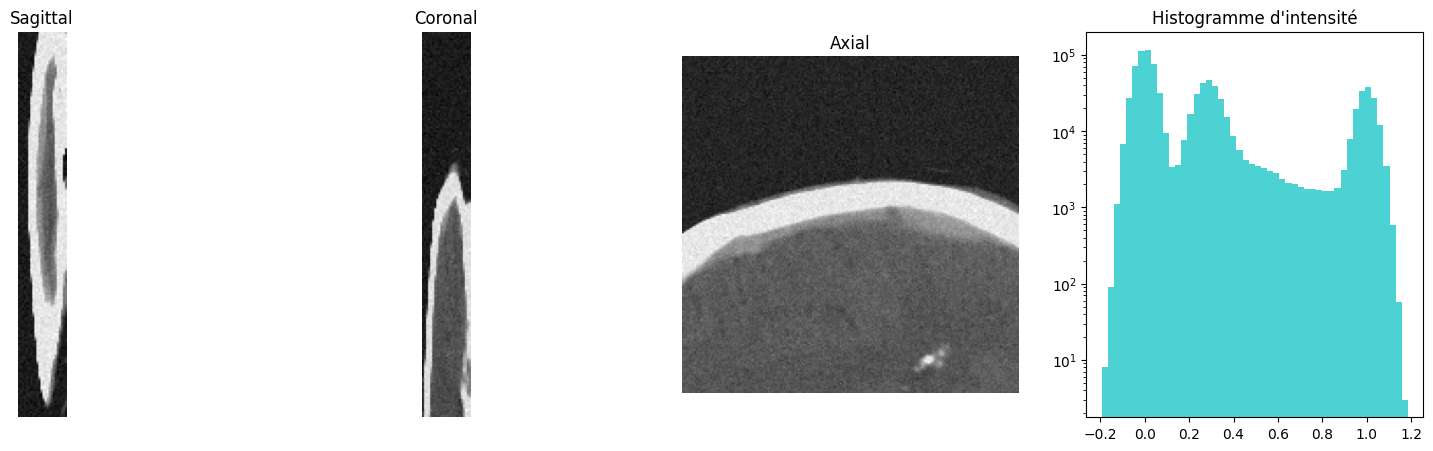

In [58]:
step5_transforms = T.Compose([
    T.RandFlipd(keys=["image", "seg"], spatial_axis=[0, 1, 2], prob=1.0), # Forcé à 1.0 pour voir l'effet
    T.RandGaussianNoised(keys=["image"], prob=1.0, mean=0.0, std=0.05), # Forcé à 1.0
])

data_step5 = step5_transforms(data_step4) # On transforme le patch
visualize_step(data_step5, "ÉTAPE 5 : Augmentations (Bruit + Flip)")

In [4]:
# 1. Obtenir le premier batch du Dataloader
first_batch = next(iter(train_loader))
    
    # 2. Extraire les tenseurs d'image (x) et de segmentation (y)
x = first_batch["image"]
print(f"Shape du tenseur 'image' (x) : {x.shape}")

y = first_batch["seg"]
print(f"Shape du tenseur 'seg' (y) : {y.shape}")

second_batch = next(iter(val_loader))
x_val = second_batch["image"]
print(f"Shape du tenseur 'image' (x) : {x_val.shape}")
y_val = second_batch["seg"]
print(f"Shape du tenseur 'seg' (y) : {y_val.shape}")

/home/tibia/miniconda3/envs/libmtl/lib/python3.10/site-packages/monai/data/dataset.py:386: UserWarning: Corrupt cache file detected: /home/tibia/Projet_Hemorragie/vf_split_3_2sample/cache_train/01be5f823263b37e471690dd8ba6fcf7.pt. Deleting and recomputing.
  warnings.warn(f"Corrupt cache file detected: {hashfile}. Deleting and recomputing.")
/home/tibia/miniconda3/envs/libmtl/lib/python3.10/site-packages/monai/data/dataset.py:386: UserWarning: Corrupt cache file detected: /home/tibia/Projet_Hemorragie/vf_split_3_2sample/cache_train/8f44ddb3c1cc474d40c8d05b17d63ae7.pt. Deleting and recomputing.
  warnings.warn(f"Corrupt cache file detected: {hashfile}. Deleting and recomputing.")
/home/tibia/miniconda3/envs/libmtl/lib/python3.10/site-packages/monai/data/dataset.py:386: UserWarning: Corrupt cache file detected: /home/tibia/Projet_Hemorragie/vf_split_3_2sample/cache_train/d51e7b56c46102cc632f7ec58196ad30.pt. Deleting and recomputing.
  warnings.warn(f"Corrupt cache file detected: {hashfil

Shape du tenseur 'image' (x) : torch.Size([4, 1, 96, 96, 96])
Shape du tenseur 'seg' (y) : torch.Size([4, 1, 96, 96, 96])


/home/tibia/miniconda3/envs/libmtl/lib/python3.10/site-packages/monai/data/dataset.py:386: UserWarning: Corrupt cache file detected: /home/tibia/Projet_Hemorragie/vf_split_3_2sample/cache_val/bb5889039a7069272ccf6efbff4e0fbc.pt. Deleting and recomputing.
  warnings.warn(f"Corrupt cache file detected: {hashfile}. Deleting and recomputing.")
/home/tibia/miniconda3/envs/libmtl/lib/python3.10/site-packages/monai/data/dataset.py:386: UserWarning: Corrupt cache file detected: /home/tibia/Projet_Hemorragie/vf_split_3_2sample/cache_val/501be512139ba52048751268f7a850fd.pt. Deleting and recomputing.
  warnings.warn(f"Corrupt cache file detected: {hashfile}. Deleting and recomputing.")
/home/tibia/miniconda3/envs/libmtl/lib/python3.10/site-packages/monai/data/dataset.py:386: UserWarning: Corrupt cache file detected: /home/tibia/Projet_Hemorragie/vf_split_3_2sample/cache_val/d6b214bffc245717e93424c64638c704.pt. Deleting and recomputing.
  warnings.warn(f"Corrupt cache file detected: {hashfile}. De

Shape du tenseur 'image' (x) : torch.Size([1, 1, 199, 203, 138])
Shape du tenseur 'seg' (y) : torch.Size([1, 1, 199, 203, 138])


In [6]:
from monai.networks import nets as monai_nets

model = monai_nets.UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=6,
    channels=(32, 64, 128, 256, 320, 320),
    strides=(2, 2, 2, 2, 2),
    num_res_units=2,
)
print (f" y ? : {y.dtype} , de shape : {y.shape} ")
y_logits = model(x)
print(f"Shape du tenseur 'y_logits' (sortie du modèle) : {y_logits.shape}")

from monai.metrics import DiceHelper
dice_metric = DiceHelper(include_background=False,
                                      #softmax=True,
                                      apply_argmax=False,
                                      num_classes=6,
                                      reduction='none')

y_labels = torch.argmax(y_logits, dim=1, keepdim=True)
print(f"Shape du tenseur 'y_labels' (après argmax) : {y_labels.shape}")



dice_scores, _ = dice_metric(y_logits, y)
print(f"Shape du tenseur 'dice_scores' : {dice_scores.shape}")

dice_scores_2, _ = dice_metric(y_labels, y)
print(f"Shape du tenseur 'dice_scores_2' : {dice_scores_2.shape}")

 y ? : torch.float32 , de shape : torch.Size([4, 1, 96, 96, 96]) 
Shape du tenseur 'y_logits' (sortie du modèle) : torch.Size([4, 6, 96, 96, 96])
Shape du tenseur 'y_labels' (après argmax) : torch.Size([4, 1, 96, 96, 96])
Shape du tenseur 'dice_scores' : torch.Size([4, 5])
Shape du tenseur 'dice_scores_2' : torch.Size([4, 5])


In [ ]:
import os
import glob
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.ndimage import label, find_objects

# --- CONFIGURATION ---
DATA_DIR = "/home/tibia/Projet_Hemorragie/Split_Final_Stratified/train/seg"
PIXDIM = [0.488281, 0.488281, 5.392519]  # (x, y, z) en mm
VOXEL_VOL_MM3 = np.prod(PIXDIM) # ~1.28 mm3
VOXEL_VOL_CM3 = VOXEL_VOL_MM3 / 1000.0

CLASSES = {
    1: "EDH",
    2: "IVH",
    3: "IPH",
    4: "SAH",
    5: "SDH"
}

def analyze_hemorrhages(data_dir):
    mask_files = sorted(glob.glob(os.path.join(data_dir, "*.nii*")))
    
    if not mask_files:
        print(f"ERREUR: Aucun fichier trouvé dans {data_dir}")
        return

    records = []

    print(f"Analyse de {len(mask_files)} fichiers...")

    for filepath in mask_files:
        filename = os.path.basename(filepath)
        try:
            # Chargement Nifti
            nii = nib.load(filepath)
            data = nii.get_fdata().astype(np.uint8)
        except Exception as e:
            print(f"Erreur lecture {filename}: {e}")
            continue

        # Pour chaque type d'hémorragie
        for class_id, class_name in CLASSES.items():
            # Créer un masque binaire pour cette classe
            binary_mask = (data == class_id)
            
            if not np.any(binary_mask):
                continue

            # Connected Component Analysis
            # structure=np.ones((3,3,3)) définit une connectivité 26 (diagonales incluses)
            labeled_array, num_features = label(binary_mask, structure=np.ones((3,3,3)))
            
            # find_objects récupère les "slices" (bounding boxes) de chaque blob
            objects = find_objects(labeled_array)

            for idx, slice_obj in enumerate(objects):
                if slice_obj is None: continue
                
                # Isoler le blob courant
                # On utilise le slice pour extraire juste la zone d'intérêt (optimisation mémoire)
                blob_mask = (labeled_array[slice_obj] == (idx + 1))
                
                # 1. Volume
                voxel_count = np.sum(blob_mask)
                volume_cm3 = voxel_count * VOXEL_VOL_CM3

                # 2. Extension Spatiale (Bounding Box physique)
                # slice_obj est un tuple de slices (slice_x, slice_y, slice_z)
                # .start et .stop donnent les indices
                
                # Calcul de l'étendue en pixels
                dx_pix = slice_obj[0].stop - slice_obj[0].start
                dy_pix = slice_obj[1].stop - slice_obj[1].start
                dz_pix = slice_obj[2].stop - slice_obj[2].start
                
                # Conversion en mm
                extent_x_mm = dx_pix * PIXDIM[0]
                extent_y_mm = dy_pix * PIXDIM[1]
                extent_z_mm = dz_pix * PIXDIM[2]

                records.append({
                    "filename": filename,
                    "class_name": class_name,
                    "lesion_id": idx + 1, # ID unique de la lésion dans ce patient
                    "volume_cm3": round(volume_cm3, 4),
                    "extent_x_mm": round(extent_x_mm, 2),
                    "extent_y_mm": round(extent_y_mm, 2),
                    "extent_z_mm": round(extent_z_mm, 2),
                    "voxel_count": voxel_count
                })

    # Création du DataFrame
    df = pd.DataFrame(records)
    
    if df.empty:
        print("Aucune hémorragie détectée.")
        return None

    return df

# --- EXÉCUTION ---
df_results = analyze_hemorrhages(DATA_DIR)

if df_results is not None:
    # 1. Sauvegarde brute
    df_results.to_csv("analyse_hemorragies_details.csv", index=False)
    
    # 2. Résumé Statistique (Ce que tu veux vraiment)
    print("\n=== MOYENNES PAR TYPE (Volume en cm3) ===")
    summary = df_results.groupby("class_name")["volume_cm3"].agg(['count', 'mean', 'std', 'min', 'max'])
    print(summary)

    print("\n=== EXTENSION SPATIALE MOYENNE (mm) ===")
    spatial_summary = df_results.groupby("class_name")[["extent_x_mm", "extent_y_mm", "extent_z_mm"]].mean()
    print(spatial_summary)